# Decision Tree C5.0 With SMOTE


## preparation

In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn import preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import joblib
import time
import resource
from google.colab import drive
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn import preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import ast
from collections import Counter
import numpy as np
import math
import joblib
from numpy import mean
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import time
import resource


## load data

In [4]:
from google.colab import drive
drive.mount('/content/drive')
data =pd.read_csv('/content/drive/MyDrive/Textmining/metode/DATA/PREPROCESSING/preprofix.csv', delimiter=";")
## Membaca file Excel dari Google Drive dan menyimpannya ke dalam DataFrame
# data = pd.read_csv("https://raw.githubusercontent.com/08-Ahlaqul-Karimah/Pariwisata-New/main/Total%20Data.csv", delimiter=";")
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,index,lokasi,Sentimen,komentar,clean,tokenize,normalize,stopword,stemming
0,0,0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '..."
1,1,1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'air', 'terjun', 'diata...","['tempat', 'bagus', 'air', 'terjun', 'atas', '..."
2,2,2,Air terjun toroan,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus']
3,3,3,Air terjun toroan,Positif,Mantap,Mantap,['mantap'],['mantap'],['mantap'],['mantap']
4,4,4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"['pemandangan', 'yg', 'indah', 'adem', 'pula',...","['pemandangan', 'yang', 'indah', 'adem', 'pula...","['pemandangan', 'indah', 'adem', 'suasanyanya'...","['pandang', 'indah', 'adem', 'suasanyanya', 'p..."


## preprocessing

In [6]:
# #mengubah result
# label=[]
# for index, row in data.iterrows():#Ini adalah loop yang berjalan melalui setiap baris dalam DataFrame 'df'
#   if row["Sentimen"] == 'Positif':
#     label.append(1)
#   elif row["Sentimen"] == 'Negatif':
#     label.append(-1)
#   else:
#     label.append(0)

# data['label']=label
# data=data.drop(columns=['Sentimen'])
# data.head()

In [7]:
import ast
import pandas as pd
from collections import Counter

# Fungsi untuk mengubah string list ke list of words
def convert_text_list(texts):
    try:
        texts = ast.literal_eval(texts)
        return texts
    except (SyntaxError, ValueError):
        return []

# Menerapkan fungsi convert_text_list pada kolom 'stemming'
data["stemming_list"] = data["stemming"].apply(convert_text_list)

# # Memastikan 'stemming_list' adalah list of words
# print("Data Stemming List:")
# print(data[["stemming_list"]])

# Fungsi untuk menghitung term frequency (TF) dari list of words
def compute_tf(text_list):
    term_count = Counter(text_list)
    total_terms = len(text_list)
    tf_dict = {term: count / total_terms for term, count in term_count.items()}
    return tf_dict

In [8]:
data["stemming_list"] = data["stemming"].apply(convert_text_list)
data

,Unnamed: 0,index,lokasi,Sentimen,komentar,clean,tokenize,normalize,stopword,stemming,stemming_list
0,0,0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","[air, terjun, bagus, tiket, masuk, murah, ribu..."
1,1,1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'air', 'terjun', 'diata...","['tempat', 'bagus', 'air', 'terjun', 'atas', '...","[tempat, bagus, air, terjun, atas, rest, area,..."
2,2,2,Air terjun toroan,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]
3,3,3,Air terjun toroan,Positif,Mantap,Mantap,['mantap'],['mantap'],['mantap'],['mantap'],[mantap]
4,4,4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"['pemandangan', 'yg', 'indah', 'adem', 'pula',...","['pemandangan', 'yang', 'indah', 'adem', 'pula...","['pemandangan', 'indah', 'adem', 'suasanyanya'...","['pandang', 'indah', 'adem', 'suasanyanya', 'p...","[pandang, indah, adem, suasanyanya, pinggir, l..."
...,...,...,...,...,...,...,...,...,...,...,...
5643,5643,5730,toron simalem,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]
5644,5644,5731,toron simalem,Positif,Siiiip,Siiiip,['siiiip'],['siiiip'],['siiiip'],['siiiip'],[siiiip]
5645,5645,5732,toron simalem,Positif,serru,serru,['serru'],['serru'],['serru'],['serru'],[serru]
5646,5646,5733,toron simalem,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]


## TF-IDF

In [9]:
# mengimpor modul numpy untuk operasi numerik
import numpy as np
# mengimpor modul math untuk fungsi-fungsi matematis
import math

In [10]:
# fungsi untuk menghitung Term Frequency (TF) dari suatu dokumen
def calculate_tf(term_frequency):
    # menghitung total kemunculan semua term dalam dokumen
    total_terms = sum(term_frequency.values())

    # menghitung nilai TF untuk setiap term dalam dokumen
    tf = {term: count / total_terms for term, count in term_frequency.items()}

    # mengembalikan dictionary yang berisi nilai TF untuk setiap term dalam dokumen.
    return tf

# fungsi untuk menghitung Inverse Document Frequency (IDF) dari kumpulan dokumen
def calculate_idf(documents):
    # jumlah total dokumen dalam kumpulan
    total_documents = len(documents)

    # inisialisasi dictionary untuk menyimpan nilai IDF untuk setiap term
    idf = {}

    # iterasi melalui setiap dokumen dalam kumpulan
    for document in documents:
        # menggunakan set untuk memastikan hanya satu perhitungan IDF untuk setiap term dalam satu dokumen
        unique_terms = set(document)

        # iterasi melalui setiap term dalam dokumen
        for term in unique_terms:
            # jika term belum ada dalam dictionary IDF, hitung dan simpan nilai IDF-nya
            if term not in idf:
                # menghitung jumlah dokumen yang mengandung term
                document_count = sum(1 for doc in documents if term in doc)
                # menggunakan rumus IDF dengan penambahan 1 untuk menghindari pembagian oleh 0
                idf[term] = math.log(total_documents / (1 + document_count))

    # mengembalikan dictionary yang berisi nilai IDF untuk setiap term dalam dokumen.
    return idf

In [11]:
# mengimpor modul Counter dari pustaka collections
# counter digunakan untuk menghitung frekuensi kemunculan term dalam suatu iterable (objek yang dapat diulang, for,loop), seperti list.
# counter akan digunakan untuk menghitung frekuensi kemunculan setiap term dalam dokumen, sehingga dapat dihitung nilai Term Frequency (TF).
from collections import Counter
preprocessing_data = data['stemming_list']

# membuat dictionary document_tf yang menyimpan Term Frequency (TF) untuk setiap dokumen dalam preprocessing_data
# dengan menggunakan fungsi calculate_tf pada setiap Counter(tokens) untuk setiap dokumen
# fungsi enumerate digunakan untuk mengambil term dari sebuah iterable bersama dengan indeks atau nomor urutnya.
document_tf = {i: calculate_tf(Counter(tokens)) for i, tokens in enumerate(preprocessing_data)}

In [12]:
document_tf

{0: {'air': 0.14285714285714285,
  'terjun': 0.14285714285714285,
  'bagus': 0.07142857142857142,
  'tiket': 0.07142857142857142,
  'masuk': 0.07142857142857142,
  'murah': 0.07142857142857142,
  'ribu': 0.07142857142857142,
  'orang': 0.07142857142857142,
  'jernih': 0.07142857142857142,
  'langsung': 0.07142857142857142,
  'berangan': 0.07142857142857142,
  'laut': 0.07142857142857142},
 1: {'tempat': 0.09090909090909091,
  'bagus': 0.09090909090909091,
  'air': 0.09090909090909091,
  'terjun': 0.09090909090909091,
  'atas': 0.09090909090909091,
  'rest': 0.09090909090909091,
  'area': 0.09090909090909091,
  'parkir': 0.09090909090909091,
  'ribu': 0.18181818181818182,
  'masuk': 0.09090909090909091},
 2: {'bagus': 1.0},
 3: {'mantap': 1.0},
 4: {'pandang': 0.09090909090909091,
  'indah': 0.09090909090909091,
  'adem': 0.09090909090909091,
  'suasanyanya': 0.09090909090909091,
  'pinggir': 0.09090909090909091,
  'laut': 0.09090909090909091,
  'cuman': 0.09090909090909091,
  'air': 0.

In [13]:
# membuat list documents yang berisi setiap kunci (term) dari dictionary Term Frequency (TF)
# untuk setiap dokumen dalam document_tf.values()
documents = [doc_tf.keys() for doc_tf in document_tf.values()]

# menghitung Inverse Document Frequency (IDF) menggunakan fungsi calculate_idf
# dengan menggunakan list documents sebagai parameter
idf = calculate_idf(documents)

In [14]:
idf

{'berangan': 7.945909598613133,
 'masuk': 2.6551204984858874,
 'tiket': 3.2824705045010654,
 'orang': 3.3457519544485854,
 'langsung': 4.054089300502506,
 'air': 2.5545573660979066,
 'murah': 3.697414356563774,
 'jernih': 4.727033773744932,
 'bagus': 1.2581777436089616,
 'terjun': 3.141888553879876,
 'laut': 3.3867833511264482,
 'ribu': 3.8027748722216,
 'parkir': 3.3973097641134355,
 'area': 4.390561537123719,
 'rest': 7.540444490504968,
 'tempat': 2.4426126513785573,
 'atas': 5.420180954304877,
 'mantap': 3.697414356563774,
 'indah': 2.1347686056364323,
 'terjunya': 7.540444490504968,
 'adem': 5.028138866528853,
 'musim': 4.464669509277441,
 'cuman': 4.6137050884379285,
 'pinggir': 4.90138716088971,
 'pandang': 2.630243593730483,
 'suasanyanya': 7.945909598613133,
 'hujan': 4.578613768626659,
 'wisata': 2.2158098156395583,
 'banget': 2.5454870091279425,
 'kunjung': 3.4350500920962825,
 'move': 7.540444490504968,
 'mantan': 6.847297309945023,
 'recomended': 5.548014325814762,
 'degan'

In [15]:
# membuat dictionary document_tfidf yang menyimpan Term Frequency-Inverse Document Frequency (TF-IDF) untuk setiap dokumen
# dengan mengalikan Term Frequency (TF) dari setiap term dalam dokumen dengan Inverse Document Frequency (IDF) dari term tersebut
document_tfidf = {}

# iterasi melalui setiap item dalam dictionary document_tf
for doc_id, doc_tf in document_tf.items():
    # menghitung TF-IDF untuk setiap term dalam dokumen dan menyimpannya dalam doc_tfidf
    doc_tfidf = {term: tf * idf[term] for term, tf in doc_tf.items()}

    # menyimpan doc_tfidf dalam dictionary document_tfidf dengan dokumen_id sebagai kunci
    document_tfidf[doc_id] = doc_tfidf

In [16]:
# Membuat DataFrame tf_idf dari dictionary document_tfidf
tf_idf = pd.DataFrame(document_tfidf)

# Mengubah orientasi DataFrame menjadi transpose (T) untuk mendapatkan dokumen sebagai baris dan term sebagai kolom
# Dengan mengubah orientasi, mendapatkan representasi DataFrame yang lebih umum digunakan dalam pemrosesan teks dan analisis data.
tf_idf = tf_idf.T

In [17]:
tf_idf

,air,terjun,bagus,tiket,masuk,murah,ribu,orang,jernih,langsung,...,tema,pertama,mamtap,bosqu,pakong,vroh,samale,serru,jenius,siiiip
0,0.364937,0.448841,0.089870,0.234462,0.189651,0.264101,0.271627,0.238982,0.337645,0.289578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.232232,0.285626,0.114380,NaN,0.241375,NaN,0.691414,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,1.258178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.232232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5643,NaN,NaN,1.258178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.94591
5645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.540444,NaN,NaN
5646,NaN,NaN,1.258178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Menggantikan nilai-nilai yang kosong (NaN) dengan 0 dalam DataFrame tfidf
tfidf = tf_idf.fillna(0)
tfidf

,air,terjun,bagus,tiket,masuk,murah,ribu,orang,jernih,langsung,...,tema,pertama,mamtap,bosqu,pakong,vroh,samale,serru,jenius,siiiip
0,0.364937,0.448841,0.089870,0.234462,0.189651,0.264101,0.271627,0.238982,0.337645,0.289578,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
1,0.232232,0.285626,0.114380,0.000000,0.241375,0.000000,0.691414,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
2,0.000000,0.000000,1.258178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
4,0.232232,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5643,0.000000,0.000000,1.258178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
5644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,7.94591
5645,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.540444,0.0,0.00000
5646,0.000000,0.000000,1.258178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000


In [19]:
# Menghitung kuartil dari jumlah data
jumlah_data_tf_idf = len(tf_idf)
print(f"Jumlah data dari tf_idf: {jumlah_data_tf_idf}")

Jumlah data dari tf_idf: 5648


## Smote

Sentimen
Positif    4209
Negatif    1049
Netral      390
Name: count, dtype: int64


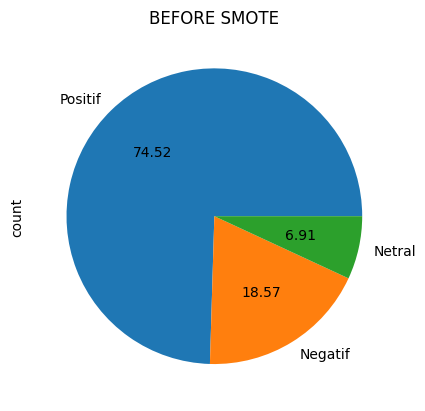

In [20]:
y = data['Sentimen']
print(pd.Series(y).value_counts())
ay = y.value_counts().plot.pie(autopct = '%.2f')
grafik = ay.set_title("BEFORE SMOTE")

Sentimen
Positif    4209
Negatif    4209
Netral     4209
Name: count, dtype: int64


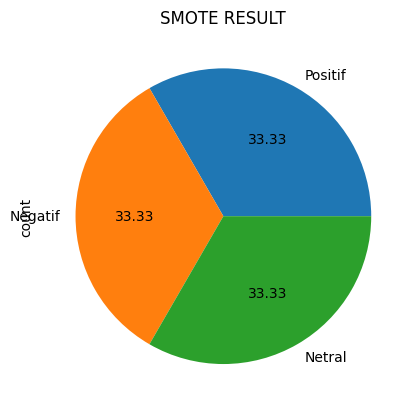

In [21]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(tfidf, y)

# Menampilkan distribusi kelas setelah oversampling
print(pd.Series(y_resampled).value_counts())

ax = y_resampled.value_counts().plot.pie(autopct='%.2f')
grafik = ax.set_title("SMOTE RESULT")

In [22]:
y_resampled

,Sentimen
0,Positif
1,Positif
2,Positif
3,Positif
4,Negatif
...,...
12622,Netral
12623,Netral
12624,Netral
12625,Netral


In [23]:
X_resampled

,air,terjun,bagus,tiket,masuk,murah,ribu,orang,jernih,langsung,...,tema,pertama,mamtap,bosqu,pakong,vroh,samale,serru,jenius,siiiip
0,0.364937,0.448841,0.089870,0.234462,0.189651,0.264101,0.271627,0.238982,0.337645,0.289578,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.232232,0.285626,0.114380,0.000000,0.241375,0.000000,0.691414,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,1.258178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.232232,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12622,0.000000,0.000000,0.088701,0.000000,0.018476,0.000000,0.241633,0.637780,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12623,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12624,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12625,0.000000,0.000000,0.003421,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Split Data

In [24]:
# Membagi Data Menjadi Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
print(f"training size {X_train.shape}")
print(f"Testing size {X_test.shape}")

training size (10101, 4216)
Testing size (2526, 4216)


## Modelling

Evaluasi K-Fold Cross Validation:
K-Fold 1:
  Accuracy:  86.24%
  Precision: 86.35%
  Recall:    86.18%
  F1-Score:  86.24%
K-Fold 2:
  Accuracy:  86.09%
  Precision: 86.18%
  Recall:    86.07%
  F1-Score:  86.12%
K-Fold 3:
  Accuracy:  86.78%
  Precision: 87.07%
  Recall:    86.84%
  F1-Score:  86.91%
K-Fold 4:
  Accuracy:  87.23%
  Precision: 87.47%
  Recall:    87.28%
  F1-Score:  87.35%
K-Fold 5:
  Accuracy:  86.29%
  Precision: 86.14%
  Recall:    86.07%
  F1-Score:  86.05%

Rata-rata Evaluasi dari semua fold:
Rata-rata Accuracy:  86.53%
Rata-rata Precision: 86.64%
Rata-rata Recall:    86.49%
Rata-rata F1-Score:  86.54%

Evaluasi pada data Testing:
Accuracy:  86.14%
Precision: 86.62%
Recall:    86.25%
F1-Score:  86.39%
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.84      0.86       868
      Netral       0.94      0.90      0.92       794
     Positif       0.79      0.84      0.82       864

    accuracy             

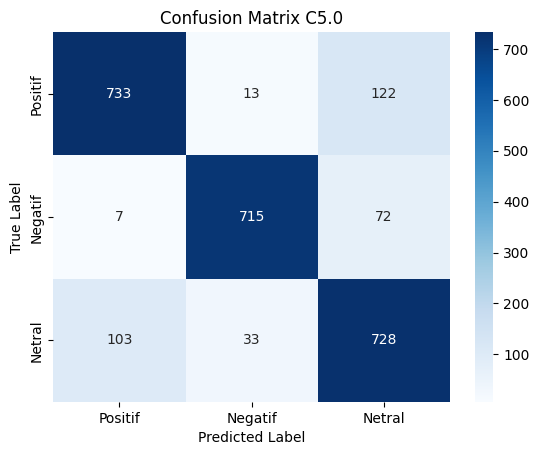

Confusion Matrix:
[[733  13 122]
 [  7 715  72]
 [103  33 728]]
waktu komputasi modelling =  22.3 secs   2.5 MByte


In [25]:
# Model training
time_start = time.perf_counter()
modelc50 = DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=42)

# Evaluasi dengan K-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Menyimpan nilai akurasi, presisi, recall, dan f1-score untuk setiap fold
model_accuracy_scores = []
model_precision_scores = []
model_recall_scores = []
model_f1_scores = []
temp_for_joblib=1
print('Evaluasi K-Fold Cross Validation:')
for i, (train_index, val_index) in enumerate(cv.split(X_train), 1):
    # print(train_index)
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Melatih model pada data latih fold
    modelc50.fit(X_train_fold, y_train_fold)
    modelc50.feature_names=X_train_fold.columns


    # Prediksi pada data validasi fold
    y_val_pred = modelc50.predict(X_val_fold)

    # Hitung metrik evaluasi
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average='macro')
    recall = recall_score(y_val_fold, y_val_pred, average='macro')
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    modelc50.accuracy = accuracy
    modelc50.precision = precision
    modelc50.recall = recall
    modelc50.f1 = f1

    joblib.dump(modelc50,f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/SMOTE/model_C50{temp_for_joblib}.joblib')

    model_accuracy_scores.append(accuracy)
    model_precision_scores.append(precision)
    model_recall_scores.append(recall)
    model_f1_scores.append(f1)

    print(f"K-Fold {i}:")
    print("  Accuracy:  {:.2f}%".format(accuracy * 100))
    print("  Precision: {:.2f}%".format(precision * 100))
    print("  Recall:    {:.2f}%".format(recall * 100))
    print("  F1-Score:  {:.2f}%".format(f1 * 100))
    temp_for_joblib+=1

print("\nRata-rata Evaluasi dari semua fold:")
print(f"Rata-rata Accuracy:  {np.mean(model_accuracy_scores)*100:.2f}%")
print(f"Rata-rata Precision: {np.mean(model_precision_scores)*100:.2f}%")
print(f"Rata-rata Recall:    {np.mean(model_recall_scores)*100:.2f}%")
print(f"Rata-rata F1-Score:  {np.mean(model_f1_scores)*100:.2f}%")
model_accuracy_scores.append(np.mean(model_accuracy_scores))
model_precision_scores.append(np.mean(model_precision_scores))
model_recall_scores.append(np.mean(model_recall_scores))
model_f1_scores.append(np.mean(model_f1_scores))


nilai_maksimum = max(model_accuracy_scores[:-1])
indeks_maksimum = model_accuracy_scores.index(nilai_maksimum)+1
modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/SMOTE/model_C50{indeks_maksimum}.joblib')

# Evaluasi model pada data testing
print("\nEvaluasi pada data Testing:")
model_y_test_pred = modelc50.predict(X_test)
accuracy1 = accuracy_score(y_test, model_y_test_pred)
model_accuracy_scores.append(accuracy1)
print("Accuracy:  {:.2f}%".format(accuracy1 * 100))
precision1 = precision_score(y_test, model_y_test_pred, average='macro')
model_precision_scores.append(precision1)
print("Precision: {:.2f}%".format(precision1 * 100))
recall1 = recall_score(y_test, model_y_test_pred, average='macro')
model_recall_scores.append(recall1)
print("Recall:    {:.2f}%".format(recall1 * 100))
f1score = f1_score(y_test, model_y_test_pred, average='macro')
model_f1_scores.append(f1score)
print("F1-Score:  {:.2f}%".format(f1score * 100))
print("Classification Report:")
print(classification_report(y_test, model_y_test_pred))

# Membuat confusion matrix
confusion = confusion_matrix(y_test, model_y_test_pred)
class_label = ["Positif", "Negatif", "Netral"]  # Sesuaikan ini dengan label dataset Anda
confusion_df = pd.DataFrame(confusion, index=class_label, columns=class_label)
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix C5.0")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Confusion Matrix:")
print(confusion)

# Komputasi
modelling_time_elapsed = (time.perf_counter() - time_start)
modelling_memMb=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024.0/1024.0
print ("waktu komputasi modelling = %5.1f secs %5.1f MByte" % (modelling_time_elapsed,modelling_memMb))


Text(0, 0.5, 'persentase (%)')

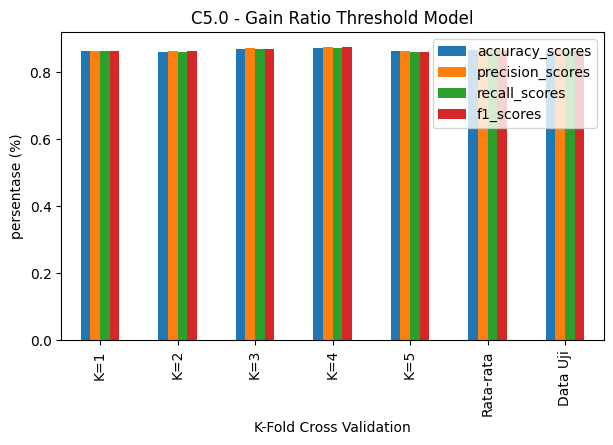

In [26]:
c = {
    "accuracy_scores":model_accuracy_scores,
    "precision_scores":model_precision_scores,
    "recall_scores":model_recall_scores,
    "f1_scores":model_f1_scores

}

plotdata = pd.DataFrame(c,
    index=["K=1",
    "K=2",
    "K=3",
    "K=4",
    "K=5",
    "Rata-rata",
    "Data Uji"])

plotdata.plot(kind="bar",figsize=(7, 4))

plt.title("C5.0 - Gain Ratio Threshold Model")

plt.xlabel("K-Fold Cross Validation")

plt.ylabel("persentase (%)")

## Gain Ratio


In [27]:
# # Memeriksa apakah semua fitur numerik. Jika tidak, harus dikonversi.
# if not all([pd.api.types.is_numeric_dtype(X_train[col]) for col in X_train.columns]):
#     X_train = pd.get_dummies(X_train)
#     X_test = pd.get_dummies(X_test)

#     # Menyamakan kolom antara X_train dan X_test setelah One-Hot Encoding
#     X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# # Mengonversi label ke numerik jika belum dalam bentuk numerik
# label_encoder = LabelEncoder()
# y_train_encoded = label_encoder.fit_transform(y_train)
# y_test_encoded = label_encoder.transform(y_test)  # Juga mengonversi y_test

# # Fungsi untuk menghitung Gain Ratio
# def calculate_gain_ratio(X, y):
#     # Menghitung mutual information (serupa dengan informasi gain)
#     mutual_info = mutual_info_classif(X, y,random_state=42, discrete_features=False)
#     # Menghitung entropy dari label
#     entropy_y = -np.sum([p * np.log2(p) for p in np.bincount(y) / len(y)])
#     # Menghitung Gain Ratio
#     gain_ratio = mutual_info / entropy_y
#     return gain_ratio

# # Menghitung Gain Ratio untuk setiap fitur
# gain_ratios = calculate_gain_ratio(X_train, y_train_encoded)

In [28]:
pd_gain_ratios=pd.read_csv("/content/drive/MyDrive/Textmining/metode/DATA/PREPROCESSING/gain_ratios.csv")
pd_gain_ratios=pd_gain_ratios.drop(columns="Unnamed: 0")
# pd_gain_ratios

In [29]:
gain_ratios=pd_gain_ratios.to_numpy()
# gaian_r=gaian_r[:,1:]
gain_ratios

array([[0.00734666],
       [0.00465416],
       [0.05097184],
       ...,
       [0.        ],
       [0.00077912],
       [0.        ]])

In [30]:
gain_ratios=gain_ratios.reshape(-1)
gain_ratios

array([0.00734666, 0.00465416, 0.05097184, ..., 0.        , 0.00077912,
       0.        ])

In [31]:
print(len(gain_ratios))
print(len(X_train.columns))
for i in range(len(gain_ratios)):
  print(X_train.columns[i],":",gain_ratios[i])
# for i in range(gain_ratios)

4216
4216
air : 0.0073466576871439
terjun : 0.0046541612183134
bagus : 0.0509718371617838
tiket : 0.0099200814120061
masuk : 0.029605895205868
murah : 0.0068310737061183
ribu : 0.0120331126817088
orang : 0.0148980330557679
jernih : 0.0
langsung : 0.0097921205189625
berangan : 0.0038005561715647
laut : 0.0065735247267149
tempat : 0.010464867689593
atas : 0.0
rest : 0.0
area : 0.0025109618313274
parkir : 0.009651038120868
mantap : 0.0120978213354483
pandang : 0.0119739938792535
indah : 0.0244911594493256
adem : 0.009361090463271
suasanyanya : 0.0001671331030544
pinggir : 0.0014142541286123
cuman : 0.0046988744806655
terjunya : 0.0048686988280104
musim : 0.0078374055841253
hujan : 0.0078163641751917
wisata : 0.0168415087612105
keren : 0.0131600332608135
recomended : 0.0020555161963254
banget : 0.0094537538681085
kunjung : 0.0095695041949583
kuliner : 0.0003189855352644
es : 0.0010253429590338
degan : 0.0028149662653031
move : 0.0027694818385732
on : 0.0
mantan : 0.0
restoran : 0.0
harga :

### Mean


In [32]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)  # Juga mengonversi y_test

Total fitur yang telah diseleksi:  1488
Evaluasi K-Fold Cross Validation:
K-Fold 1:
  Accuracy:  86.00%
  Precision: 86.05%
  Recall:    85.92%
  F1-Score:  85.97%
K-Fold 2:
  Accuracy:  84.41%
  Precision: 84.36%
  Recall:    84.37%
  F1-Score:  84.36%
K-Fold 3:
  Accuracy:  86.29%
  Precision: 86.53%
  Recall:    86.35%
  F1-Score:  86.40%
K-Fold 4:
  Accuracy:  86.49%
  Precision: 86.61%
  Recall:    86.58%
  F1-Score:  86.59%
K-Fold 5:
  Accuracy:  84.90%
  Precision: 84.78%
  Recall:    84.69%
  F1-Score:  84.68%

Rata-rata Evaluasi dari semua fold:
Rata-rata Accuracy:  85.62%
Rata-rata Precision: 85.67%
Rata-rata Recall:    85.58%
Rata-rata F1-Score:  85.60%

Evaluasi pada data Testing:
Accuracy:  84.60%
Precision: 84.92%
Recall:    84.77%
F1-Score:  84.81%
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.82      0.84       868
      Netral       0.91      0.91      0.91       794
     Positif       0.77      0.82      0

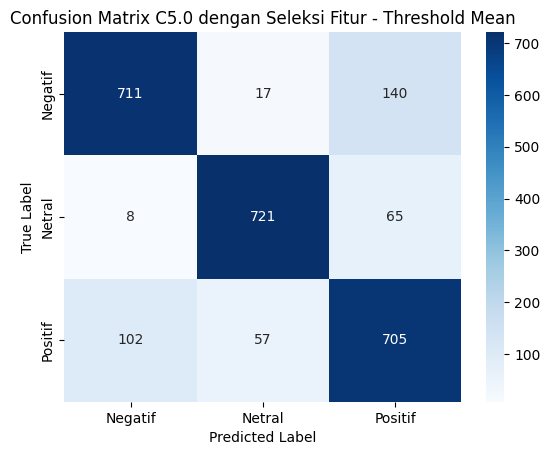

Confusion Matrix:
[[711  17 140]
 [  8 721  65]
 [102  57 705]]
Waktu komputasi: 9.97 detik
Penggunaan memori: 2.47 MB


In [33]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import resource
import warnings

# Mengabaikan semua peringatan
warnings.filterwarnings('ignore')

# Mulai pengukuran waktu komputasi
time_start = time.perf_counter()


# Menentukan threshold sebagai rata-rata Gain Ratio
threshold = gain_ratios.mean()

# Memilih fitur yang Gain Ratio-nya di atas threshold
selected_features = X_train.columns[gain_ratios > threshold]
print('Total fitur yang telah diseleksi: ', len(selected_features))

# Menggunakan fitur yang dipilih untuk pelatihan model
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Model training
modelc50 = DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=42)

# Evaluasi dengan K-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Menyimpan nilai akurasi, presisi, recall, dan f1-score untuk setiap fold
mean_accuracy_scores = []
mean_precision_scores = []
mean_recall_scores = []
mean_f1_scores = []

temp_for_joblib=1
print('Evaluasi K-Fold Cross Validation:')
for i, (train_index, val_index) in enumerate(cv.split(X_train_selected), 1):
    # print(temp_for_joblib)
    X_train_fold, X_val_fold = X_train_selected.iloc[train_index], X_train_selected.iloc[val_index]
    y_train_fold, y_val_fold = y_train_encoded[train_index], y_train_encoded[val_index]
    temp=0

    # # Melatih model pada data latih fold
    # modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/SMOTE/mean_C50_{temp_for_joblib}.joblib')

    # Melatih model pada data latih fold
    modelc50.fit(X_train_fold, y_train_fold)
    modelc50.feature_names=X_train_fold.columns
    for i in modelc50.feature_names:
      if i not in X_val_fold.columns:
        X_val_fold.insert(temp, i, 0)
      temp+=1
    ft=[]
    for i in modelc50.feature_names:
      ft.append(i)
    X_val_fold=X_val_fold[ft]

    # Prediksi pada data validasi fold
    y_val_pred = modelc50.predict(X_val_fold)

    # Hitung metrik evaluasi
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average='macro')
    recall = recall_score(y_val_fold, y_val_pred, average='macro')
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    modelc50.accuracy=accuracy
    modelc50.precision=precision
    modelc50.recall=recall
    modelc50.f1=f1


    joblib.dump(modelc50,f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/SMOTE/mean_C50_{temp_for_joblib}.joblib')
    # Simpan metrik evaluasi
    mean_accuracy_scores.append(accuracy)
    mean_precision_scores.append(precision)
    mean_recall_scores.append(recall)
    mean_f1_scores.append(f1)

    print(f"K-Fold {temp_for_joblib}:")
    print(f"  Accuracy:  {accuracy * 100:.2f}%")
    print(f"  Precision: {precision * 100:.2f}%")
    print(f"  Recall:    {recall * 100:.2f}%")
    print(f"  F1-Score:  {f1 * 100:.2f}%")
    temp_for_joblib+=1

# Menampilkan rata-rata evaluasi dari semua fold
print("\nRata-rata Evaluasi dari semua fold:")
print(f"Rata-rata Accuracy:  {np.mean(mean_accuracy_scores) * 100:.2f}%")
print(f"Rata-rata Precision: {np.mean(mean_precision_scores) * 100:.2f}%")
print(f"Rata-rata Recall:    {np.mean(mean_recall_scores) * 100:.2f}%")
print(f"Rata-rata F1-Score:  {np.mean(mean_f1_scores) * 100:.2f}%")
mean_accuracy_scores.append(np.mean(mean_accuracy_scores))
mean_precision_scores.append(np.mean(mean_precision_scores))
mean_recall_scores.append(np.mean(mean_recall_scores))
mean_f1_scores.append(np.mean(mean_f1_scores))

# Evaluasi model pada data testing

nilai_maksimum = max(model_accuracy_scores[:-1])
# indeks_maksimum = model_accuracy_scores.index(nilai_maksimum)+1

modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/SMOTE/mean_C50_{indeks_maksimum}.joblib')

print("\nEvaluasi pada data Testing:")
temp=0
for i in modelc50.feature_names:
  if i not in X_test_selected.columns:
    X_test_selected.insert(temp, i, 0)
  temp+=1
ft=[]
for i in modelc50.feature_names:
  ft.append(i)
X_test_selected=X_test_selected[ft]
mean_y_test_pred = modelc50.predict(X_test_selected)
mean_y_test_encoded = y_test_encoded
accuracy_test = accuracy_score(mean_y_test_encoded, mean_y_test_pred)
precision_test = precision_score(mean_y_test_encoded, mean_y_test_pred, average='macro')
recall_test = recall_score(mean_y_test_encoded, mean_y_test_pred, average='macro')
f1_test = f1_score(mean_y_test_encoded, mean_y_test_pred, average='macro')
mean_accuracy_scores.append(accuracy_test)
mean_precision_scores.append(precision_test)
mean_recall_scores.append(recall_test)
mean_f1_scores.append(f1_test)
print(f"Accuracy:  {accuracy_test * 100:.2f}%")
print(f"Precision: {precision_test * 100:.2f}%")
print(f"Recall:    {recall_test * 100:.2f}%")
print(f"F1-Score:  {f1_test * 100:.2f}%")

# Menampilkan Classification Report
print("Classification Report:")
mean_y_test_encoded=label_encoder.inverse_transform(mean_y_test_encoded)
mean_y_test_pred=label_encoder.inverse_transform(mean_y_test_pred)
print(classification_report(mean_y_test_encoded, mean_y_test_pred))

# Membuat confusion matrix
confusion = confusion_matrix(mean_y_test_encoded, mean_y_test_pred)
class_labels = label_encoder.classes_  # Gunakan label yang sesuai dengan dataset
confusion_df = pd.DataFrame(confusion, index=class_labels, columns=class_labels)
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix C5.0 dengan Seleksi Fitur - Threshold Mean")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Confusion Matrix:")
print(confusion)

# Pengukuran waktu komputasi dan penggunaan memori
time_elapsed = (time.perf_counter() - time_start)
mem_usage_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0 / 1024.0
print(f"Waktu komputasi: {time_elapsed:.2f} detik")
print(f"Penggunaan memori: {mem_usage_mb:.2f} MB")

# Plotting the tree (jika diperlukan)
# plt.figure(figsize=(12, 8))
# from sklearn import tree
# tree.plot_tree(modelc50, filled=True, class_names=class_labels, feature_names=selected_features)
# plt.title("Decision Tree - C5.0 dengan Seleksi Fitur")
# plt.show()


Text(0, 0.5, 'persentase (%)')

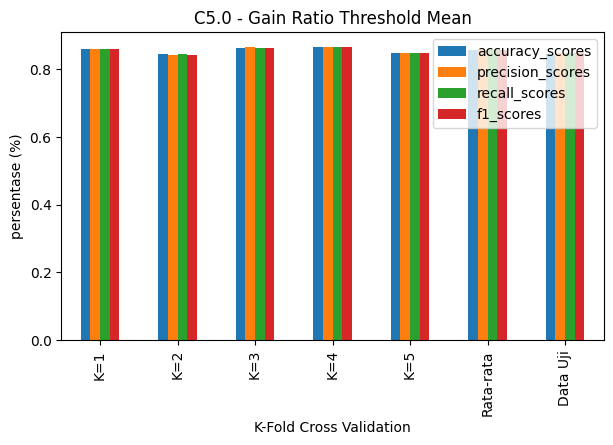

In [34]:
c = {
    "accuracy_scores":mean_accuracy_scores,
    "precision_scores":mean_precision_scores,
    "recall_scores":mean_recall_scores,
    "f1_scores":mean_f1_scores

}

plotdata = pd.DataFrame(c,
    index=["K=1",
    "K=2",
    "K=3",
    "K=4",
    "K=5",
    "Rata-rata",
    "Data Uji"])

plotdata.plot(kind="bar",figsize=(7, 4))

plt.title("C5.0 - Gain Ratio Threshold Mean")

plt.xlabel("K-Fold Cross Validation")

plt.ylabel("persentase (%)")

In [35]:
X_train_selected

,air,terjun,bagus,tiket,masuk,murah,ribu,orang,langsung,berangan,...,sajadah,perempuan,amanah,rami,keluargs,mtr,tiru,pertama,vroh,samale
472,0.638639,0.785472,0.000000,0.0,0.000000,0.0,0.0,0.0,1.013522,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10415,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12175,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11569,0.000000,0.000000,0.019525,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12461,0.000000,0.000000,0.029127,0.0,0.061467,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5191,0.000000,0.000000,0.629089,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Median

Total fitur yang telah diseleksi:  2108
Evaluasi K-Fold Cross Validation:
K-Fold 1:
  Accuracy:  85.21%
  Precision: 85.42%
  Recall:    85.15%
  F1-Score:  85.23%
K-Fold 2:
  Accuracy:  85.79%
  Precision: 85.88%
  Recall:    85.75%
  F1-Score:  85.81%
K-Fold 3:
  Accuracy:  86.58%
  Precision: 86.81%
  Recall:    86.64%
  F1-Score:  86.70%
K-Fold 4:
  Accuracy:  87.33%
  Precision: 87.57%
  Recall:    87.38%
  F1-Score:  87.46%
K-Fold 5:
  Accuracy:  85.79%
  Precision: 85.59%
  Recall:    85.54%
  F1-Score:  85.53%

Rata-rata Evaluasi dari semua fold:
Rata-rata Accuracy:  86.14%
Rata-rata Precision: 86.25%
Rata-rata Recall:    86.09%
Rata-rata F1-Score:  86.14%

Evaluasi pada data Testing:
Accuracy:  85.63%
Precision: 86.08%
Recall:    85.77%
F1-Score:  85.87%
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.83      0.85       868
      Netral       0.93      0.91      0.92       794
     Positif       0.78      0.84      0

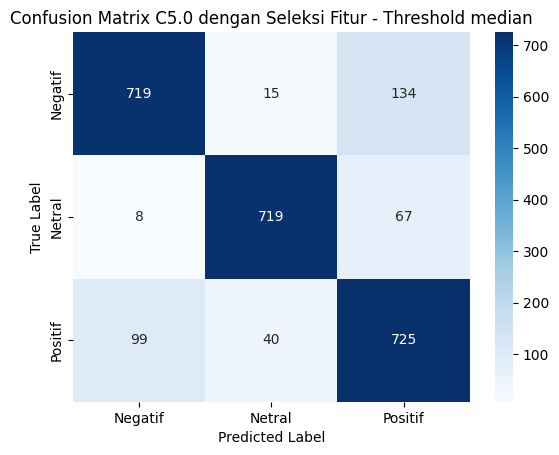

Confusion Matrix:
[[719  15 134]
 [  8 719  67]
 [ 99  40 725]]
Waktu komputasi: 12.89 detik
Penggunaan memori: 2.47 MB


In [36]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import resource
import warnings

# Mengabaikan semua peringatan
warnings.filterwarnings('ignore')

# Mulai pengukuran waktu komputasi
time_start = time.perf_counter()


# Menentukan threshold sebagai rata-rata Gain Ratio
threshold = np.median(gain_ratios)

# Memilih fitur yang Gain Ratio-nya di atas threshold
selected_features = X_train.columns[gain_ratios > threshold]
print('Total fitur yang telah diseleksi: ', len(selected_features))

# Menggunakan fitur yang dipilih untuk pelatihan model
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Model training
modelc50 = DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=42)

# Evaluasi dengan K-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Menyimpan nilai akurasi, presisi, recall, dan f1-score untuk setiap fold
median_accuracy_scores = []
median_precision_scores = []
median_recall_scores = []
median_f1_scores = []

temp_for_joblib=1
print('Evaluasi K-Fold Cross Validation:')
for i, (train_index, val_index) in enumerate(cv.split(X_train_selected), 1):
    # print(temp_for_joblib)
    X_train_fold, X_val_fold = X_train_selected.iloc[train_index], X_train_selected.iloc[val_index]
    y_train_fold, y_val_fold = y_train_encoded[train_index], y_train_encoded[val_index]
    temp=0

    # Melatih model pada data latih fold
    # modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/SMOTE/median_C50_{temp_for_joblib}.joblib')

    # Melatih model pada data latih fold
    modelc50.fit(X_train_fold, y_train_fold)
    modelc50.feature_names=X_train_fold.columns
    for i in modelc50.feature_names:
      if i not in X_val_fold.columns:
        X_val_fold.insert(temp, i, 0)
      temp+=1
    ft=[]
    for i in modelc50.feature_names:
      ft.append(i)
    X_val_fold=X_val_fold[ft]

    # Prediksi pada data validasi fold
    y_val_pred = modelc50.predict(X_val_fold)


    # Hitung metrik evaluasi
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average='macro')
    recall = recall_score(y_val_fold, y_val_pred, average='macro')
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    modelc50.accuracy=accuracy
    modelc50.precision=precision
    modelc50.recall=recall
    modelc50.f1=f1

    joblib.dump(modelc50,f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/SMOTE/median_C50_{temp_for_joblib}.joblib')
    # Simpan metrik evaluasi
    median_accuracy_scores.append(accuracy)
    median_precision_scores.append(precision)
    median_recall_scores.append(recall)
    median_f1_scores.append(f1)

    print(f"K-Fold {temp_for_joblib}:")
    print(f"  Accuracy:  {accuracy * 100:.2f}%")
    print(f"  Precision: {precision * 100:.2f}%")
    print(f"  Recall:    {recall * 100:.2f}%")
    print(f"  F1-Score:  {f1 * 100:.2f}%")
    temp_for_joblib+=1

# Menampilkan rata-rata evaluasi dari semua fold
print("\nRata-rata Evaluasi dari semua fold:")
print(f"Rata-rata Accuracy:  {np.mean(median_accuracy_scores) * 100:.2f}%")
print(f"Rata-rata Precision: {np.mean(median_precision_scores) * 100:.2f}%")
print(f"Rata-rata Recall:    {np.mean(median_recall_scores) * 100:.2f}%")
print(f"Rata-rata F1-Score:  {np.mean(median_f1_scores) * 100:.2f}%")
median_accuracy_scores.append(np.mean(median_accuracy_scores))
median_precision_scores.append(np.mean(median_precision_scores))
median_recall_scores.append(np.mean(median_recall_scores))
median_f1_scores.append(np.mean(median_f1_scores))

# Evaluasi model pada data testing

nilai_maksimum = max(model_accuracy_scores[:-1])
indeks_maksimum = model_accuracy_scores.index(nilai_maksimum)+1

modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/SMOTE/median_C50_{indeks_maksimum}.joblib')

print("\nEvaluasi pada data Testing:")
temp=0
for i in modelc50.feature_names:
  if i not in X_test_selected.columns:
    X_test_selected.insert(temp, i, 0)
  temp+=1
ft=[]
for i in modelc50.feature_names:
  ft.append(i)
X_test_selected=X_test_selected[ft]
median_y_test_pred = modelc50.predict(X_test_selected)
median_y_test_encoded=y_test_encoded
accuracy_test = accuracy_score(median_y_test_encoded, median_y_test_pred)
precision_test = precision_score(median_y_test_encoded, median_y_test_pred, average='macro')
recall_test = recall_score(median_y_test_encoded, median_y_test_pred, average='macro')
f1_test = f1_score(median_y_test_encoded, median_y_test_pred, average='macro')
median_accuracy_scores.append(accuracy_test)
median_precision_scores.append(precision_test)
median_recall_scores.append(recall_test)
median_f1_scores.append(f1_test)
print(f"Accuracy:  {accuracy_test * 100:.2f}%")
print(f"Precision: {precision_test * 100:.2f}%")
print(f"Recall:    {recall_test * 100:.2f}%")
print(f"F1-Score:  {f1_test * 100:.2f}%")

# Menampilkan Classification Report
print("Classification Report:")
median_y_test_encoded=label_encoder.inverse_transform(median_y_test_encoded)
median_y_test_pred=label_encoder.inverse_transform(median_y_test_pred)
print(classification_report(median_y_test_encoded, median_y_test_pred))

# Membuat confusion matrix
confusion = confusion_matrix(median_y_test_encoded, median_y_test_pred)
class_labels = label_encoder.classes_  # Gunakan label yang sesuai dengan dataset
confusion_df = pd.DataFrame(confusion, index=class_labels, columns=class_labels)
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix C5.0 dengan Seleksi Fitur - Threshold median")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Confusion Matrix:")
print(confusion)

# Pengukuran waktu komputasi dan penggunaan memori
time_elapsed = (time.perf_counter() - time_start)
mem_usage_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0 / 1024.0
print(f"Waktu komputasi: {time_elapsed:.2f} detik")
print(f"Penggunaan memori: {mem_usage_mb:.2f} MB")

# Plotting the tree (jika diperlukan)
# plt.figure(figsize=(12, 8))
# from sklearn import tree
# tree.plot_tree(modelc50, filled=True, class_names=class_labels, feature_names=selected_features)
# plt.title("Decision Tree - C5.0 dengan Seleksi Fitur")
# plt.show()


Text(0, 0.5, 'persentase (%)')

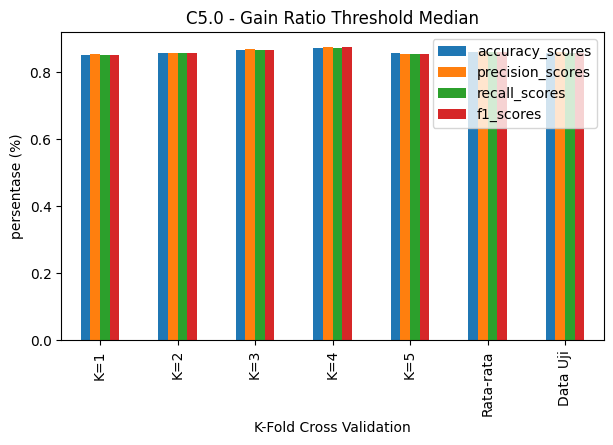

In [37]:
c = {
    "accuracy_scores":median_accuracy_scores,
    "precision_scores":median_precision_scores,
    "recall_scores":median_recall_scores,
    "f1_scores":median_f1_scores

}

plotdata = pd.DataFrame(c,
    index=["K=1",
    "K=2",
    "K=3",
    "K=4",
    "K=5",
    "Rata-rata",
    "Data Uji"])

plotdata.plot(kind="bar",figsize=(7, 4))

plt.title("C5.0 - Gain Ratio Threshold Median")

plt.xlabel("K-Fold Cross Validation")

plt.ylabel("persentase (%)")